In [2]:
import numpy as np
data = np.load("/home/notebook/data/personal/S9063410/bp_data_one_channel/OPPO_Watch4_Pro/1000135070/1000135070-20251004150950.npz")
print(list(data.keys()))
ppg = data['G0-PD0']
ecg = data["ECG"]
print("PPG Shape:", ppg.shape)
print("Duration:", data["duration"])


['duration', 'GR', 'IR', 'gyro']


KeyError: 'G0-PD0 is not a file in the archive'

keys: ['duration', 'G0-PD0', 'G0-PD1', 'G1-PD0', 'G1-PD1', 'IR0-PD0', 'IR0-PD1', 'gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']


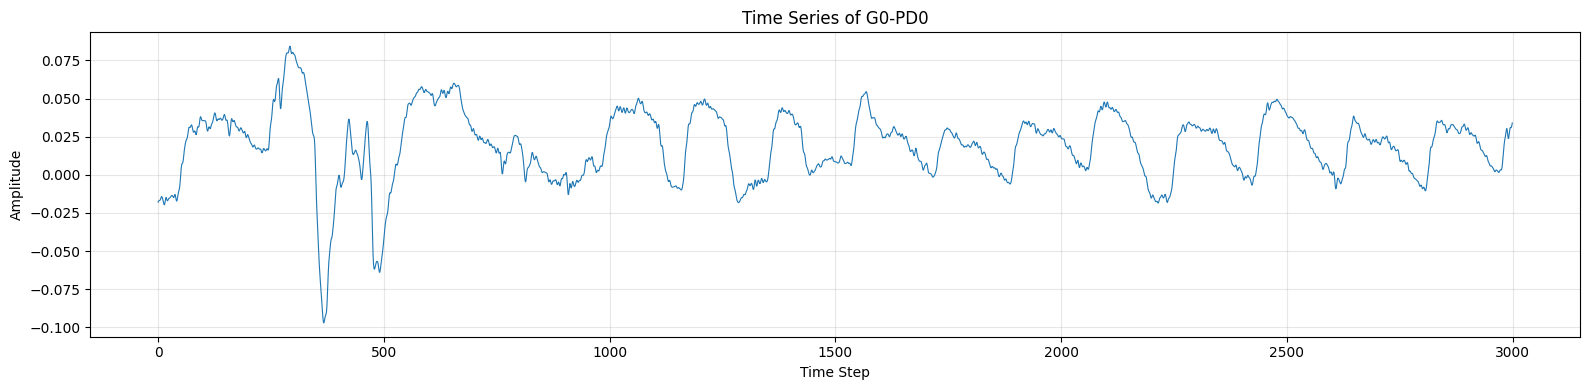

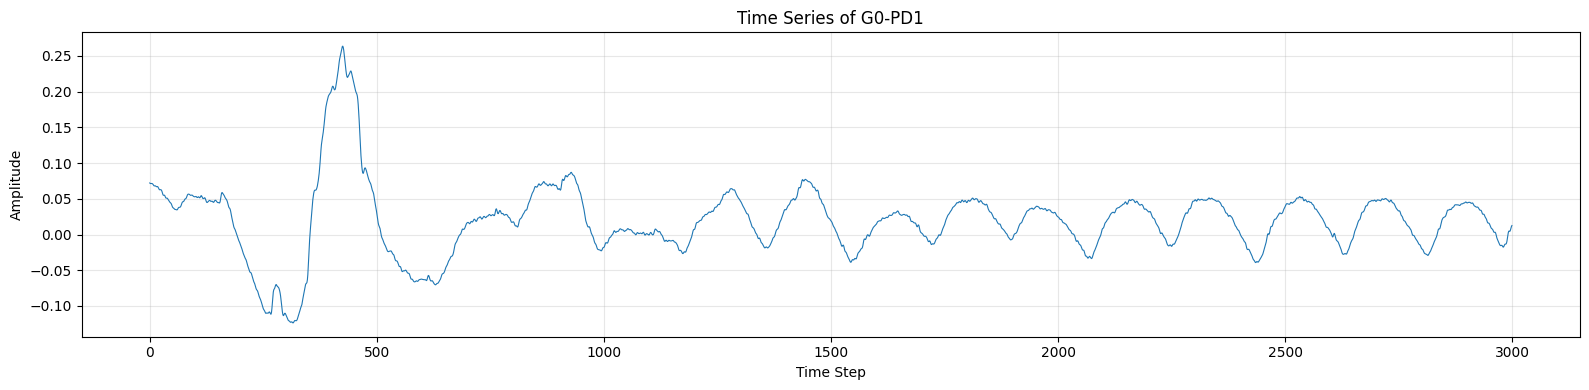

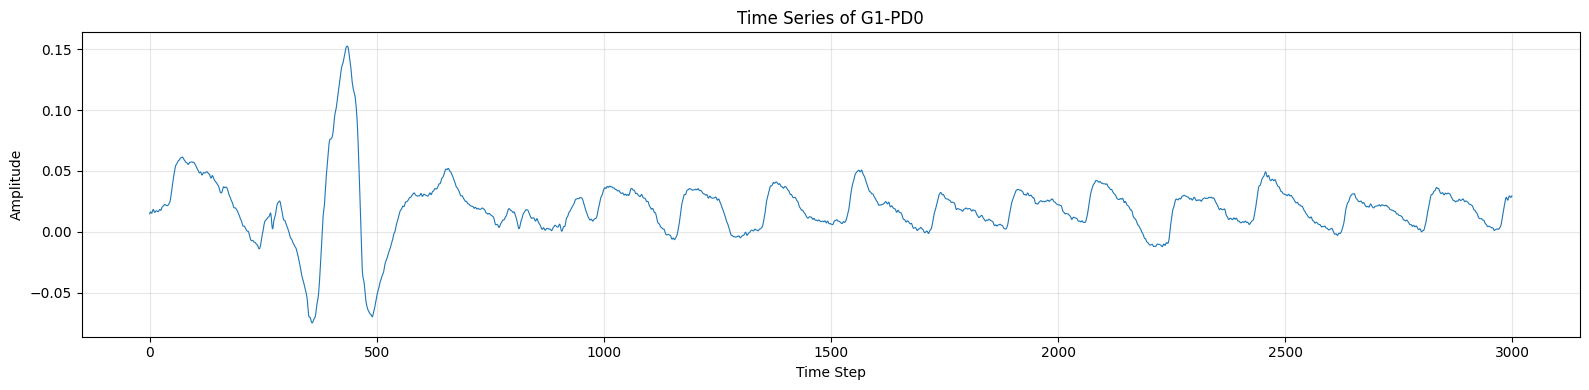

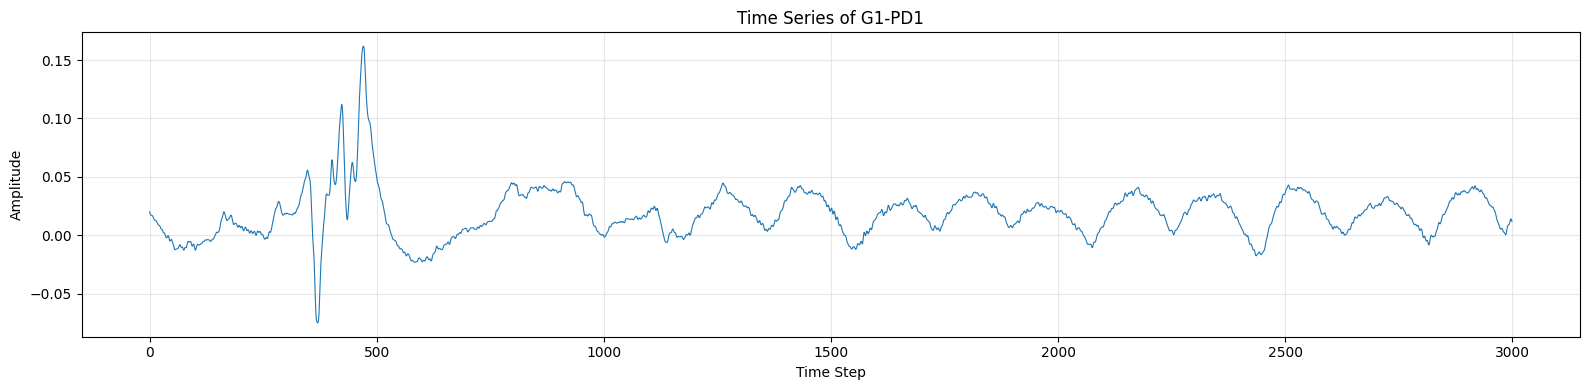

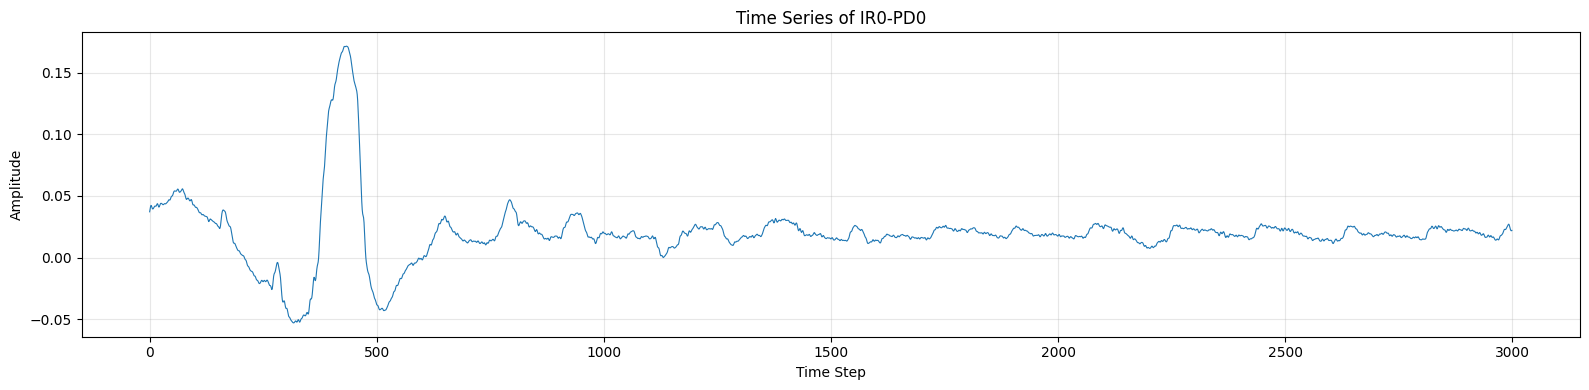

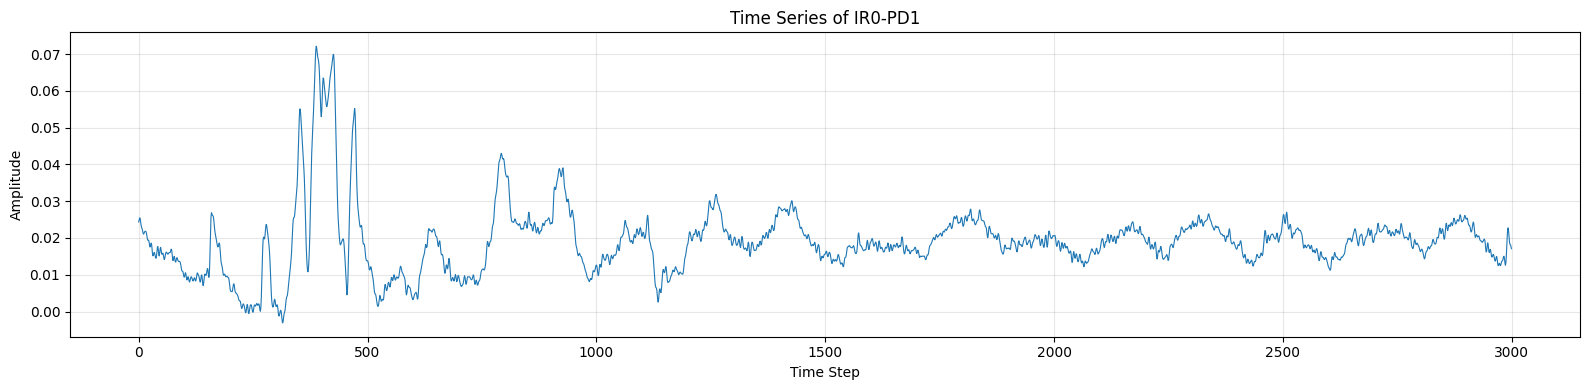

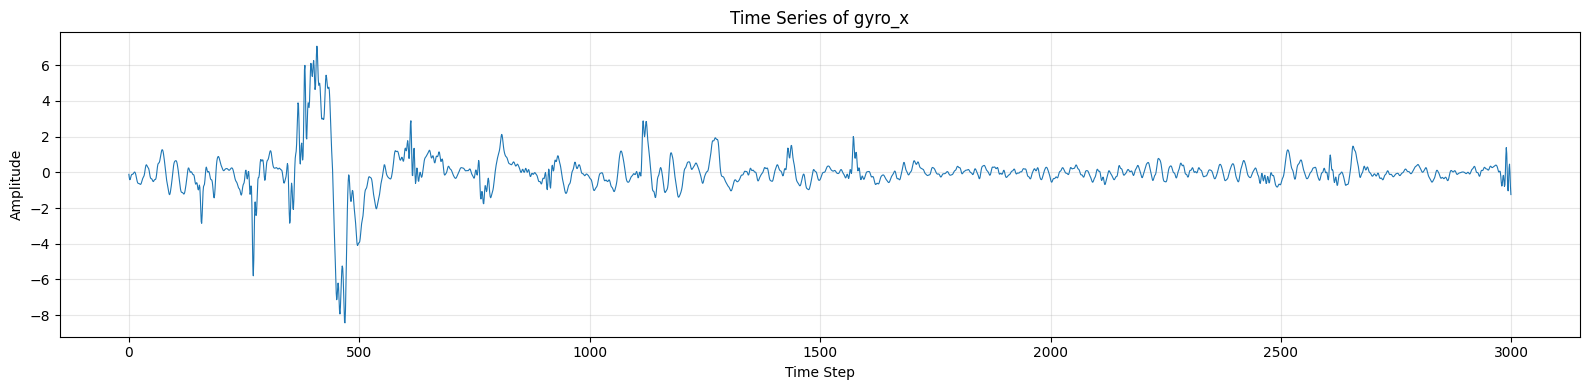

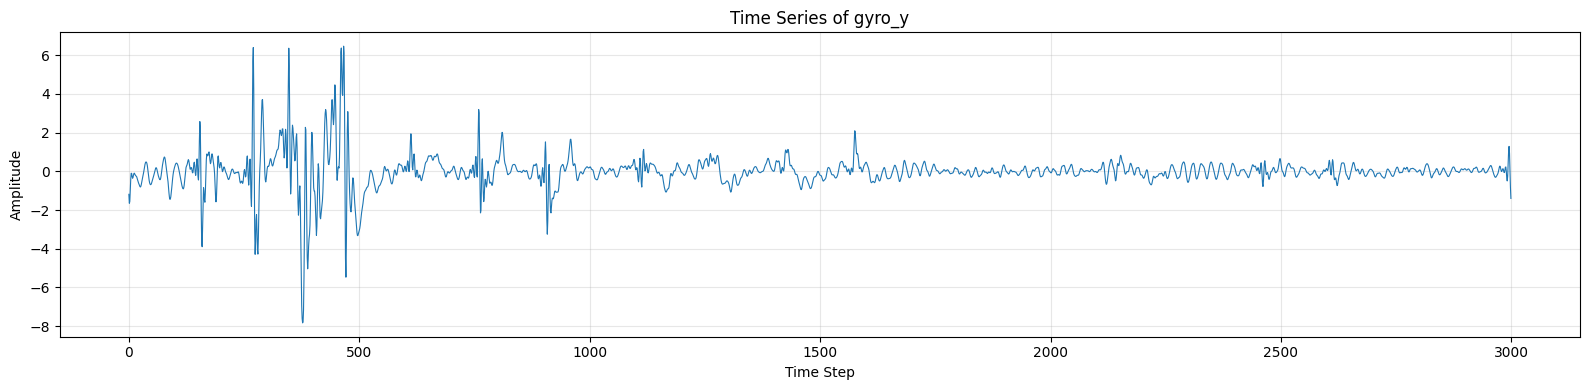

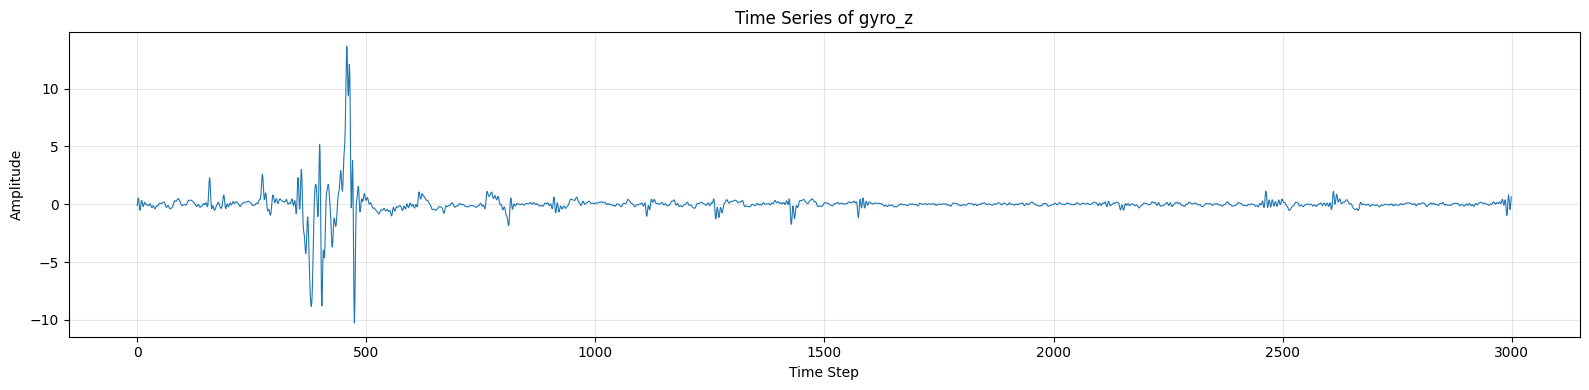

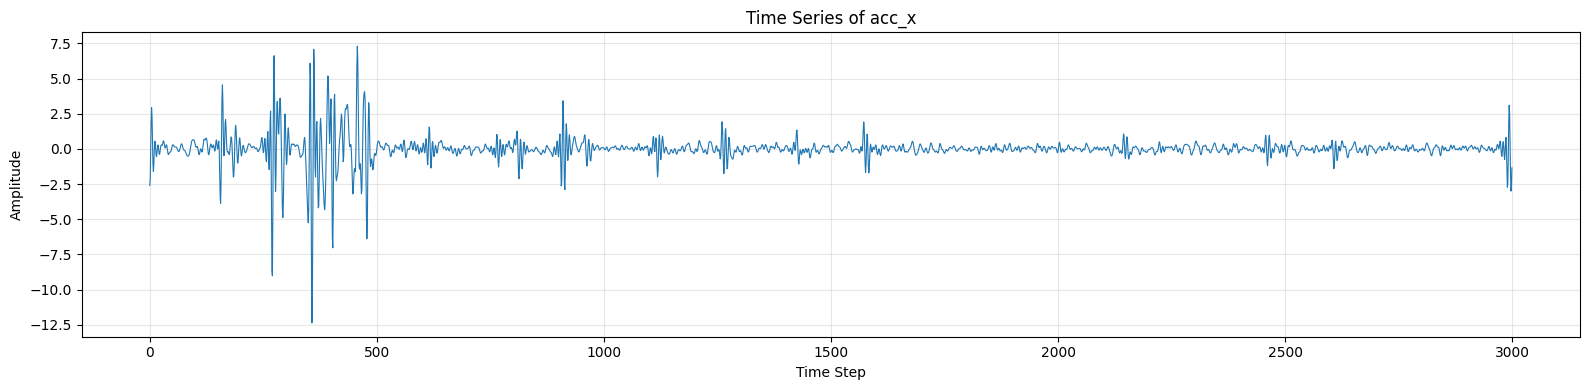

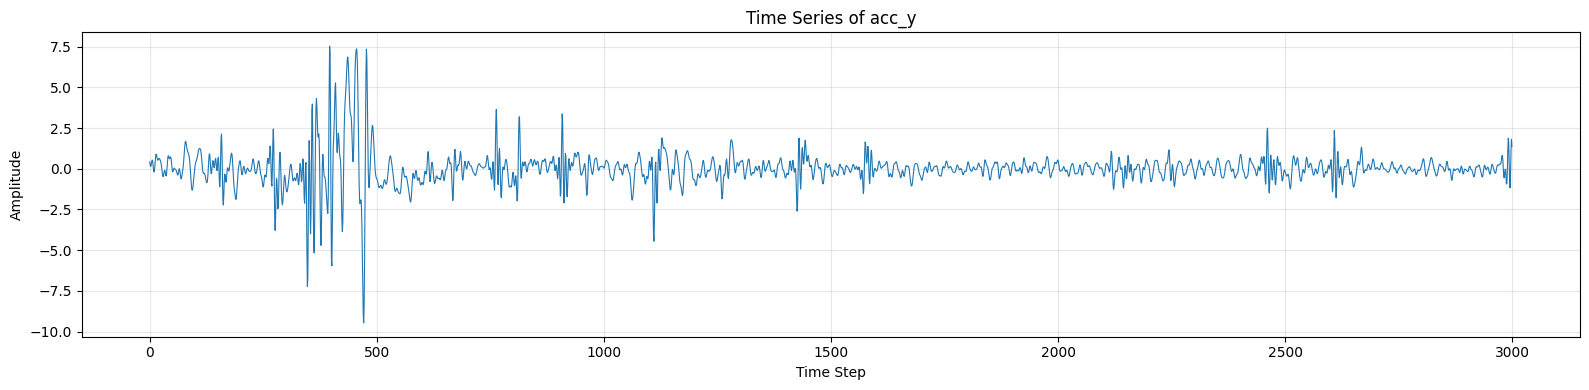

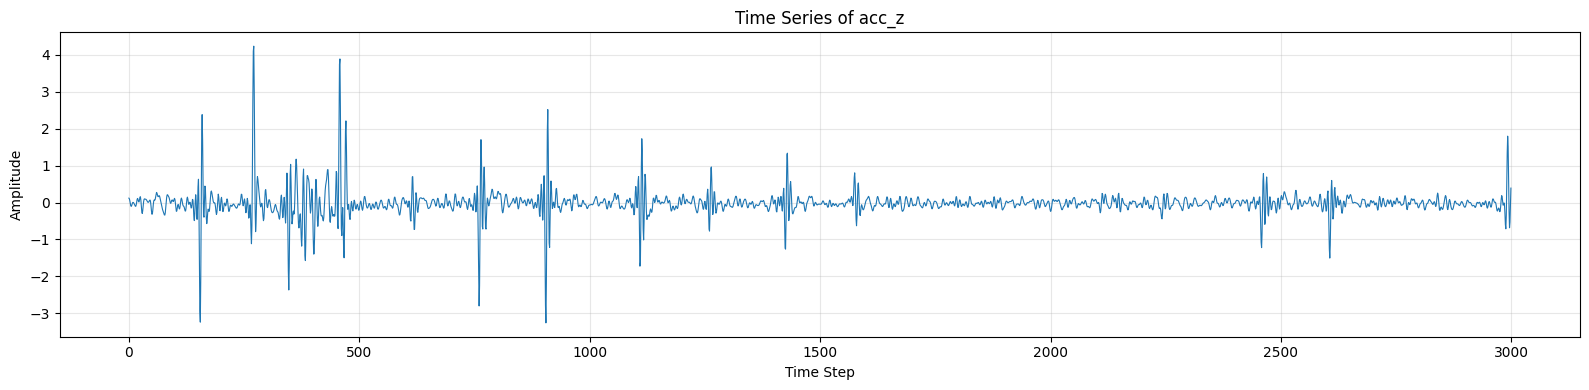

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ====== 1. 读取 npz ======
npz_path = "/home/notebook/data/personal/S9063410/pwv+bp_data_multilight/OPPO_Watch4_Pro/1000202689/1000202689-20260228114233.npz"
data = np.load(npz_path, allow_pickle=True)

print("keys:", data.files)

# ====== 2. 需要画图的信号 ======
signal_keys = [k for k in data.files if k != "duration"]

# ====== 3. 逐个画时序图 ======
for key in signal_keys:
    signal = data[key][1000:4000]

    # 有些数组可能 shape 是 (N, 1) 或 (1, N)，压成 1 维
    signal = np.squeeze(signal)

    # 跳过非一维数据
    if signal.ndim != 1:
        print(f"skip {key}: shape = {signal.shape}, not 1D")
        continue

    plt.figure(figsize=(16, 4))
    plt.plot(signal, linewidth=0.8)
    plt.title(f"Time Series of {key}")
    plt.xlabel("Time Step")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("/home/notebook/code/personal/S9063410/sleep2vec")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle
data = pickle.load(open("/home/notebook/data/personal/S9063410/bp_data_one_channel/pretrain_data/index_one_channel_test_preset_60.pickle", "rb"))
for s in data[:5]:
    print(s.payload.get("available_channels"))
print(data[0])

['ppg_green', 'ppg_infrared', 'gyro_vm']
['ppg_green', 'ppg_infrared', 'gyro_vm']
['ppg_green', 'ppg_infrared', 'gyro_vm']
['ppg_green', 'ppg_infrared', 'gyro_vm']
['ppg_green', 'ppg_infrared', 'gyro_vm']
SampleIndex(id=1038, path='/home/notebook/data/personal/S9063410/bp_data_one_channel/OPPO_Watch4_Pro/13685106/13685106-20241116053232.npz', start=0, end=15, payload={'available_channels': ['ppg_green', 'ppg_infrared', 'gyro_vm'], 'channel_sources': {'ppg_green': ['GR'], 'ppg_infrared': ['IR'], 'gyro_vm': ['gyro']}}, metadata={'age': 21.2, 'sex': 'male', 'source': '/home/notebook/data/personal/S9063410/bp_data_one_channel/index_one_channel.csv', 'path': '/home/notebook/data/personal/S9063410/bp_data_one_channel/OPPO_Watch4_Pro/13685106/13685106-20241116053232.npz', 'split': 'test'})


In [3]:
import torch
print(torch.cuda.is_bf16_supported())

True
